#Day30. 머신러닝기초
---


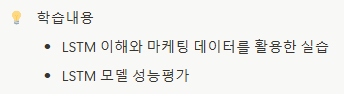

#**LSTM**

## **1. LSTM 이론**

### **1.1 LSTM(Long Short-Term Memory)의 개념**

LSTM은 RNN(Recurrent Neural Network)의 한 종류로, 장기 의존성(Long-term dependency) 문제를 해결하기 위해 개발된 모델

기본 RNN은 시간이 지남에 따라 **기울기 소실(Vanishing Gradient) 문제**가 발생하는데, LSTM은 셀 상태(Cell State)와 게이트 구조(Gates)를 활용하여 이를 해결

### **1.2 LSTM의 주요 구성 요소**

1. **셀 상태(Cell State)**: 네트워크의 장기 기억을 유지하는 경로
2. **입력 게이트(Input Gate)**: 새로운 정보를 셀 상태에 추가할지 여부 결정
3. **망각 게이트(Forget Gate)**: 불필요한 정보를 제거
4. **출력 게이트(Output Gate)**: 현재 상태에서 어떤 값을 출력할지 결정

LSTM은 이 3가지 게이트를 통해 장기 기억을 유지하면서 시계열 데이터를 효과적으로 학습할 수 있음

## **2. LSTM의 수식**

LSTM의 동작을 수식으로 정리하면 다음과 같다.

### **2.1 게이트 연산**

각 게이트는 **시그모이드(𝜎) 활성화 함수**를 사용하여 0~1 사이 값을 출력하고, 이는 얼마나 정보를 유지할지 결정한다.

- **망각 게이트(Forget Gate)**
    
    $$
    f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
    $$
    
- **입력 게이트(Input Gate)**
    
    $$
    i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
    $$
    
- **셀 상태 업데이트(Candidate Cell State)**
    
    $$
    \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)
    $$
    
- **최종 셀 상태(Cell State)**
    
    $$
    C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
    $$
    
- **출력 게이트(Output Gate)**
    
    $$
    o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
    $$
    
- **은닉 상태(hidden state) 업데이트**
    
  $$
  h_t = o_t * \tanh(C_t)
  $$
    

여기서,

- $x_t$ = 입력 데이터
- $h_{t-1}$ = 이전 은닉 상태
- $C_{t-1}$ = 이전 셀 상태
- $W_f, W_i, W_c, W_o$ = 가중치 행렬
- $b_f, b_i, b_c, b_o$ = 편향 벡터

##**3. 마케팅 데이터를 활용한 시나리오**

### **3.1 시나리오 설정**

한 전자상거래 기업이 과거 3년간의 월별 매출 데이터를 기반으로 다음 달 매출을 예측하려 한다.

- `입력 데이터(X)`: 과거 12개월의 매출
- `출력 데이터(y)`: 다음 달의 매출
- 데이터를 **LSTM 모델**로 학습하여, 패턴을 찾아 매출 변동을 예측

### **3.2 데이터**

- 데이터는 **월별 매출**로 구성되며, 3년치(36개월) 데이터를 사용한다.
- 특징(Feature)로 최근 **12개월 데이터**를 입력으로 사용하여 **다음 달 매출을 예측**하는 구조.


##**4. LSTM 실습 코드**

<ipython-input-2-08f054906b76>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.3479 - val_loss: 0.4288
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.3047 - val_loss: 0.3831
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2837 - val_loss: 0.3372
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.2638 - val_loss: 0.2898
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.2249 - val_loss: 0.2410
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1826 - val_loss: 0.1888
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1407 - val_loss: 0.1336
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1012 - val_loss: 0.0808
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0721 - val_loss: 0.0422
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0605 - val_loss: 0.0352
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0668 - val_loss: 0.0378
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.0767 - val_los

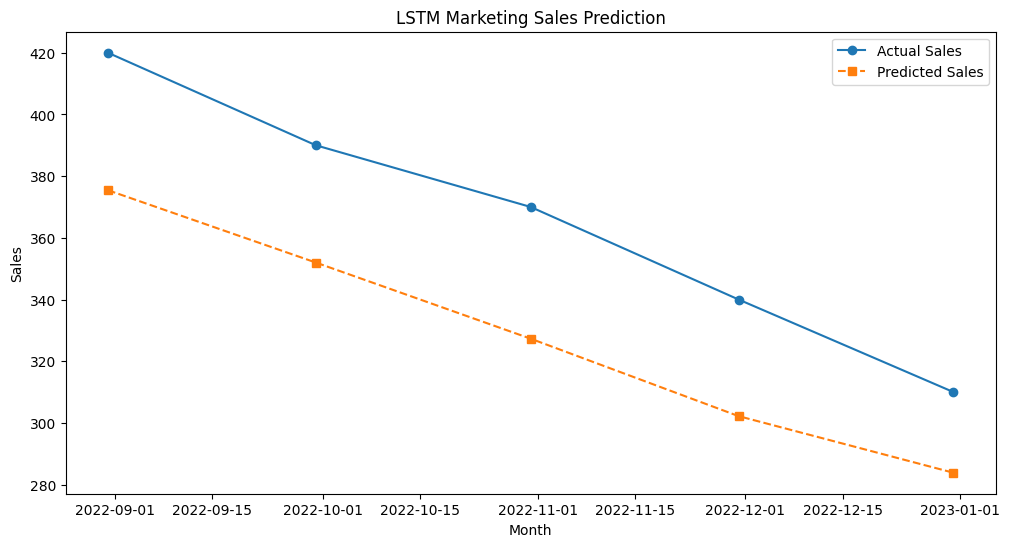

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 하드코딩된 마케팅 매출 데이터 (3년간 월별 매출)
data = {
    'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
    'Sales': [
        200, 220, 250, 270, 300, 350, 400, 380, 360, 340, 310, 280,
        240, 260, 290, 310, 340, 390, 420, 400, 370, 350, 320, 290,
        260, 280, 310, 330, 360, 410, 440, 420, 390, 370, 340, 310
    ]
}

df = pd.DataFrame(data)
df.set_index('Month', inplace=True)

# 2. 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# 3. LSTM 입력 데이터 생성 (과거 12개월 -> 다음 달 예측)
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(df_scaled, seq_length)

# 4. 학습 데이터와 테스트 데이터 분할 (80% 학습, 20% 테스트)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. LSTM 모델 구축
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])

# 6. 모델 컴파일
model.compile(optimizer='adam', loss='mse')

# 7. 모델 학습
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# 8. 예측 수행
y_pred = model.predict(X_test)

# 9. 결과 되돌리기 (Inverse Transform)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# 10. 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual Sales", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted Sales", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("LSTM Marketing Sales Prediction")
plt.legend()
plt.show()

####**epochs 변경 후 비교**

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0099 - val_loss: 0.0099
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0038 - val_loss: 7.1878e-04
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0082 - val_loss: 0.0022
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0039 - val_loss: 0.0164
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0062 - val_loss: 0.0197
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0065 - val_loss: 0.0057
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0030 - val_loss: 0.0010
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0076 - val_loss: 0.0038
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0031 - val_loss: 0.0199
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0069 - val_loss: 0.0203
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0064 - val_loss: 0.0042
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0031 - v

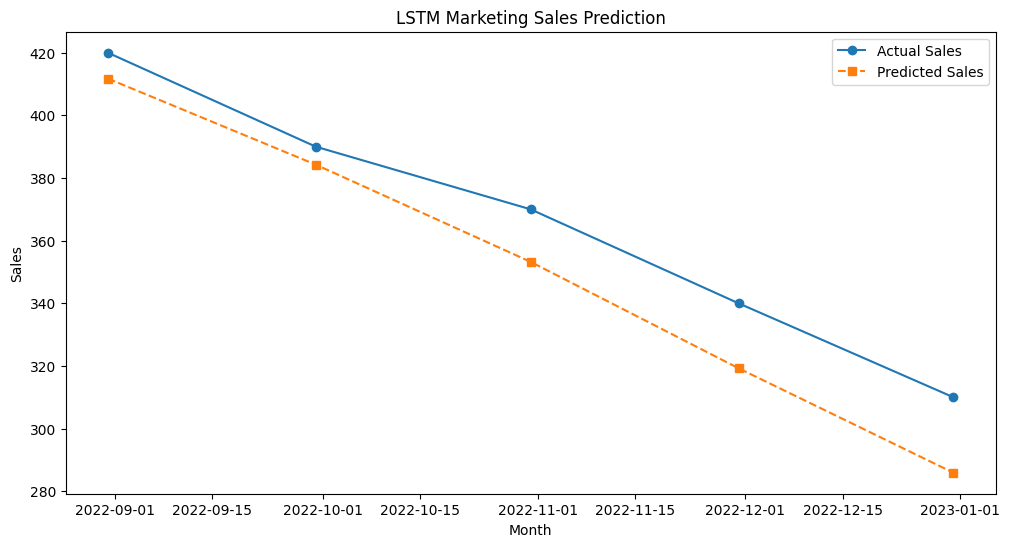

In [3]:
# 7. 모델 학습
history = model.fit(X_train, y_train, epochs=500, batch_size=16, validation_data=(X_test, y_test))

# 8. 예측 수행
y_pred = model.predict(X_test)

# 9. 결과 되돌리기 (Inverse Transform)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# 10. 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual Sales", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted Sales", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("LSTM Marketing Sales Prediction")
plt.legend()
plt.show()

1. **LSTM 모델 구조**
    - 첫 번째 LSTM 레이어 (50 뉴런, `relu` 활성화, `return_sequences=True`)
    - 두 번째 LSTM 레이어 (50 뉴런, `relu` 활성화)
    - Dense 레이어 (출력 뉴런 1개)
    - 최적화 알고리즘: Adam
    - 손실 함수: MSE (Mean Squared Error)
2. **학습 과정**
    - 과거 12개월 데이터를 입력으로 사용하여 다음 달 매출 예측
    - 100 Epoch 동안 학습 후 검증
3. **결과 시각화**
    - 실제 매출(`Actual Sales`) vs. 예측 매출(`Predicted Sales`) 그래프 출력



---

## **1. LSTM 모델 성능평가**

### **1.1 LSTM 모델 성능평가의 필요성**

LSTM 모델의 성능을 평가하는 것은 예측 모델이 얼마나 정확한지 확인하고 개선할 방향을 찾기 위해 필수적

특히, 시계열 데이터의 특성을 반영하여 모델이 과적합되지 않고 일반화 능력을 가지는지 확인해야 함

### **1.2 주요 평가 지표**

LSTM 모델의 성능을 평가할 때 주로 사용되는 지표는 다음과 같음

### **(1) 평균제곱오차(Mean Squared Error, MSE)**

$$
MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

- 예측값과 실제값의 차이를 제곱한 후 평균을 구한 값
- 값이 작을수록 모델의 예측이 정확함

### **(2) 평균절대오차(Mean Absolute Error, MAE)**

$$
MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
$$

- 예측값과 실제값의 차이를 절대값으로 변환하여 평균을 구한 값
- 모델이 얼마나 실제값에 가까운지 직관적으로 확인 가능

### **(3) 결정계수(R² Score)**

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

- 1에 가까울수록 예측 모델이 실제 데이터를 잘 설명함
- 0에 가까우면 모델의 설명력이 낮음을 의미

### **(4) 평균절대백분율오차(Mean Absolute Percentage Error, MAPE)**

$$
MAPE = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$

- 예측값의 오차를 백분율로 나타내어 상대적 성능 평가 가능

## **2. LSTM 모델 성능평가 수식**

### **2.1 손실 함수(loss function)**

LSTM 모델의 훈련 과정에서 사용되는 손실 함수는 보통 MSE(Mean Squared Error)

$$
L = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

이를 최소화하는 방향으로 모델 학습

### **2.2 성능평가 지표 수식**

- **MSE:** 모델이 실제값과 예측값 간의 차이를 얼마나 작게 만드는지 평가
- **MAE:** 예측값과 실제값 간의 절대적인 차이를 평균한 값
- **R² Score:** 모델이 얼마나 실제값을 설명할 수 있는지 측정
- **MAPE:** 상대적인 오차율을 측정하여 모델이 얼마나 정확한지를 백분율로 표시



---

### **예제 1: 고객 유지율 예측 (Customer Retention Prediction)**

### **1. 시나리오**

한 SaaS(Software as a Service) 기업은 고객 유지율(retention rate)을 예측하고자 한다.

이 기업은 매월 **구독자의 수**와 **이탈 고객 수**를 기록하여 고객 유지율을 분석한다.

LSTM 모델을 사용하여 **다음 달의 고객 유지율**을 예측하고, 이를 기반으로 마케팅 전략을 수립한다.

### **2. 데이터 정의**

- `Month`: 월별 데이터
- `Subscribers`: 해당 월의 전체 구독자 수
- `Churn`: 해당 월의 이탈 고객 수
- `Retention Rate (%)`: 고객 유지율
    
  $$
  RetentionRate = \left(1 - \frac{Churn}{Subscribers} \right) \times 100
  $$
    

### **3. 코드 (고객 유지율 예측)**

Epoch 1/100


<ipython-input-4-3588d58ccfe5>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.6057 - val_loss: 0.2238
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.5893 - val_loss: 0.1995
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.5416 - val_loss: 0.1766
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5109 - val_loss: 0.1553
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.4564 - val_loss: 0.1354
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4245 - val_loss: 0.1168
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4005 - val_loss: 0.0993
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3688 - val_loss: 0.0821
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3427 - val_loss: 0.0661
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.2877 - val_loss: 0.0511
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2706 - val_loss: 0.0365
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.2424 - val_loss: 0.0226
Epo

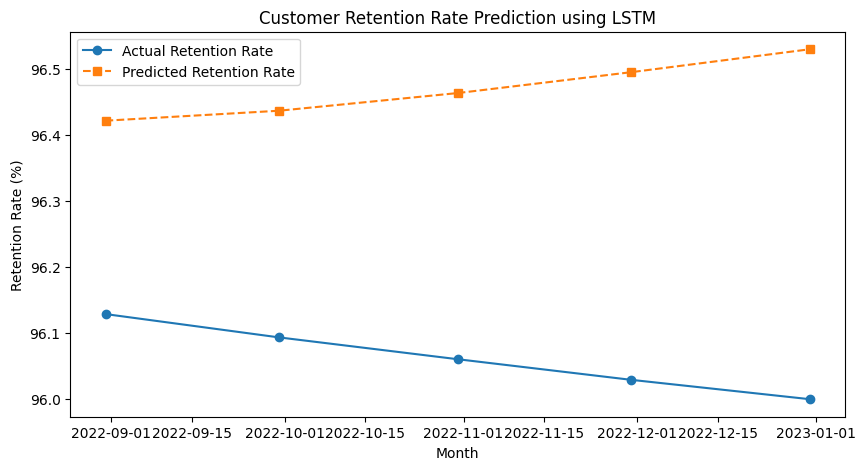

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 정의
data = {
    'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
    'Subscribers': [1000, 1050, 1100, 1200, 1300, 1400, 1500, 1550, 1600, 1700, 1750, 1800,
                    1850, 1900, 1950, 2000, 2050, 2100, 2200, 2250, 2300, 2350, 2400, 2450,
                    2500, 2550, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500],
    'Churn': [50, 40, 55, 60, 65, 70, 75, 80, 85, 90, 85, 80,
              75, 70, 65, 60, 55, 50, 50, 55, 60, 65, 70, 75,
              80, 85, 90, 95, 100, 110, 115, 120, 125, 130, 135, 140]
}
df = pd.DataFrame(data)
df['Retention Rate'] = (1 - df['Churn'] / df['Subscribers']) * 100
df.set_index('Month', inplace=True)

# 2. 데이터 정규화
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Retention Rate']])

# 3. LSTM 입력 데이터 생성
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(df_scaled, seq_length)

# 4. 모델 학습 및 예측
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# 5. 예측 및 시각화
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(10, 5))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual Retention Rate", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted Retention Rate", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("Retention Rate (%)")
plt.title("Customer Retention Rate Prediction using LSTM")
plt.legend()
plt.show()

### **예제 2: 광고 캠페인 성과 예측 (Ad Campaign Performance Prediction)**

### **1. 시나리오**

전자상거래 회사는 페이스북과 구글에서 광고를 진행하며, **월별 광고비와 매출 데이터를 기반으로 광고 성과를 예측**하고자 한다.

LSTM 모델을 사용하여 다음 달의 광고 투자 대비 매출 성과(ROAS, Return on Ad Spend)를 예측한다.

### **2. 데이터 정의**

- `Month`: 월별 데이터
- `Ad Spend`: 월별 광고비 (단위: 만원)
- `Revenue`: 월별 광고로 인한 매출 (단위: 만원)
- `ROAS`: 광고 수익률 (ROAS = Revenue / Ad Spend)

### **3. 코드 (광고 캠페인 성과 예측)**

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1488

<ipython-input-5-284134f205ac>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.1520 - val_loss: 0.0473
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0962 - val_loss: 0.0204
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0541 - val_loss: 0.0200
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0397 - val_loss: 0.0303
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0332 - val_loss: 0.0412
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0442 - val_loss: 0.0463
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0470 - val_loss: 0.0462
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0401 - val_loss: 0.0437
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0474 - val_loss: 0.0400
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0456 - val_loss: 0.0363
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0435 - val_loss: 0.0331
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0420 - val_loss: 0.0303

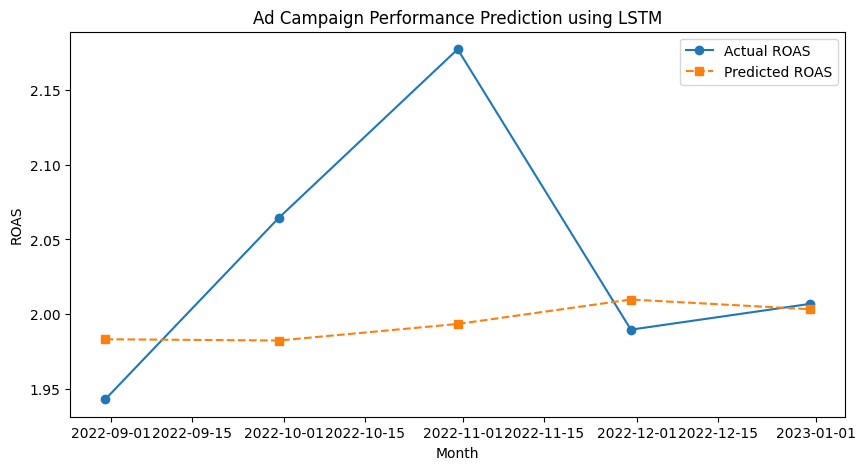

In [5]:
# 1. 데이터 정의
data = {
    'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
    'Ad Spend': np.linspace(50, 150, 36) + np.random.randn(36) * 5,  # 광고비 (만원)
    'Revenue': np.linspace(100, 300, 36) + np.random.randn(36) * 10  # 광고 매출 (만원)
}
df = pd.DataFrame(data)
df['ROAS'] = df['Revenue'] / df['Ad Spend']
df.set_index('Month', inplace=True)

# 2. 데이터 정규화 및 LSTM 적용
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['ROAS']])
X, y = create_sequences(df_scaled, seq_length=12)
train_size = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

# 3. 모델 학습 및 예측
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))
y_pred = model.predict(X_test)

# 4. 예측 결과 시각화
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(10, 5))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual ROAS", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted ROAS", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("ROAS")
plt.title("Ad Campaign Performance Prediction using LSTM")
plt.legend()
plt.show()

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0056 - val_loss: 0.0344
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0052 - val_loss: 0.0322
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0053 - val_loss: 0.0295
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0057 - val_loss: 0.0286
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0056 - val_loss: 0.0307
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0055 - val_loss: 0.0339
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0057 - val_loss: 0.0364
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0061 - val_loss: 0.0381
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0066 - val_loss: 0.0362
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0059 - val_loss: 0.0312
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0056 - val_loss: 0.0303
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0062 - val_lo

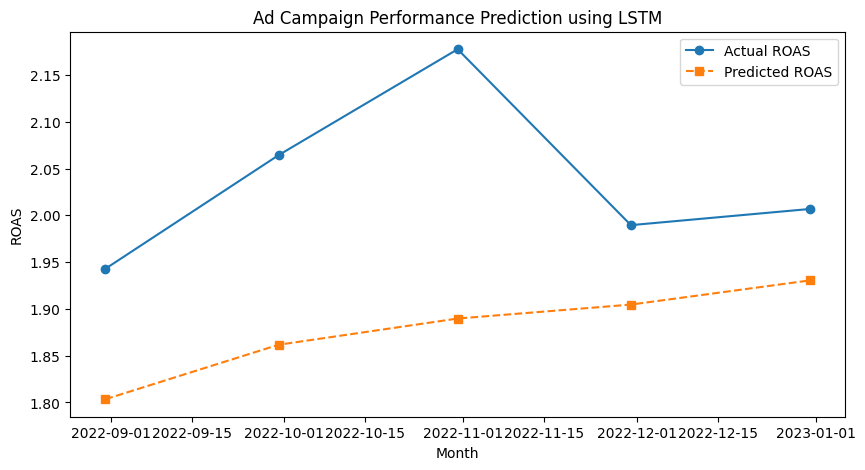

In [7]:
# 3. 모델 학습 및 예측
model.fit(X_train, y_train, epochs=300, batch_size=16, validation_data=(X_test, y_test))
y_pred = model.predict(X_test)

# 4. 예측 결과 시각화
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(10, 5))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual ROAS", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted ROAS", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("ROAS")
plt.title("Ad Campaign Performance Prediction using LSTM")
plt.legend()
plt.show()

### **예제 3: 바이럴 마케팅 효과 예측 (Viral Marketing Effect Prediction)**

### **1. 시나리오**

한 기업이 바이럴 마케팅을 진행한 후, 고객의 **소셜미디어 언급량(mentions)**이 매출에 미치는 영향을 분석하고자 한다.

LSTM을 사용하여 바이럴 마케팅이 발생한 후 **몇 개월 후까지 매출 증가가 지속되는지 예측**한다.

### **2. 데이터 정의**

- `Month`: 월별 데이터
- `Mentions`: 소셜미디어에서 해당 브랜드가 언급된 횟수
- `Sales`: 해당 월의 매출

### **3. 코드 (바이럴 마케팅 효과 예측)**

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2136

<ipython-input-8-d22d6c6a5d73>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.2020 - val_loss: 0.3970
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1023 - val_loss: 0.2928
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0460 - val_loss: 0.2317
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0175 - val_loss: 0.0830
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0154 - val_loss: 0.0178
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0084 - val_loss: 0.0705
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0115 - val_loss: 0.0199
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0099 - val_loss: 0.0039
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0065 - val_loss: 0.0052
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0061 - val_loss: 0.0034
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0046 - val_loss: 0.0044

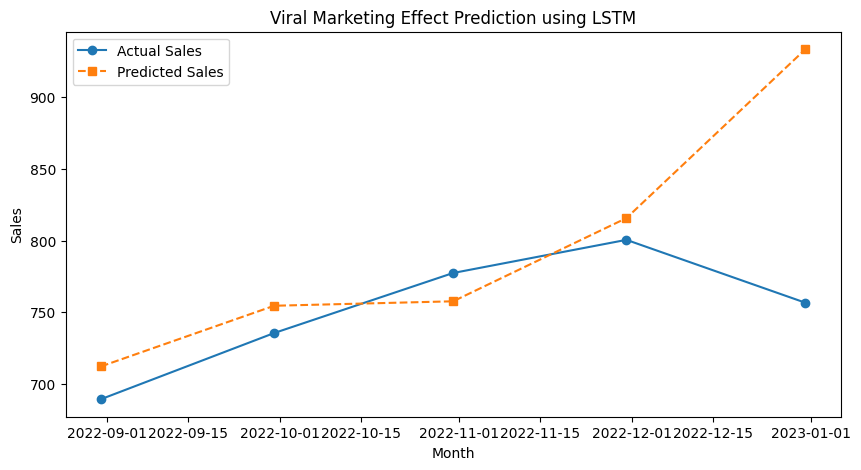

In [8]:
# 1. 데이터 생성
data = {
    'Month': pd.date_range(start='2020-01-01', periods=36, freq='M'),
    'Mentions': np.linspace(100, 500, 36) + np.random.randn(36) * 20,
    'Sales': np.linspace(200, 800, 36) + np.random.randn(36) * 30
}
df = pd.DataFrame(data)
df.set_index('Month', inplace=True)

# 2. 데이터 정규화 및 모델 학습
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Sales']])
X, y = create_sequences(df_scaled, seq_length=12)
train_size = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

# 3. 예측 결과 시각화
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(10, 5))
plt.plot(df.index[-len(y_test):], y_test_inv, label="Actual Sales", marker="o")
plt.plot(df.index[-len(y_test):], y_pred_inv, label="Predicted Sales", linestyle="--", marker="s")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Viral Marketing Effect Prediction using LSTM")
plt.legend()
plt.show()



---

## **1. 시나리오**

그로스마케팅 데이터를 기반으로 LSTM 모델을 활용하여 방문자 수, 클릭 수, 전환율 등을 예측하는 과정은 다음과 같다.

### **시나리오 개요**

1. **데이터 생성**
    - 가상의 그로스마케팅 데이터(방문자 수, 클릭 수, 전환 수, 전환율)를 생성하여 CSV 파일로 저장한다.
2. **모델 학습 및 저장**
    - CSV 데이터를 불러와 LSTM 모델을 학습하고, 학습된 모델을 파일로 저장한다.
3. **모델 로딩 및 예측**
    - 저장된 모델을 로딩하여 최근 10일 데이터를 기반으로 **미래 방문자 수 및 전환율**을 예측한다.


## **2. 데이터**

### **데이터 개요**

| Column Name | 설명 | 예시 값 |
| --- | --- | --- |
| `date` | 날짜 | 2023-01-01 |
| `visitors` | 방문자 수 | 1500 |
| `clicks` | 클릭 수 | 200 |
| `conversions` | 전환 수 | 30 |
| `conversion_rate` | 전환율 (conversions / visitors) | 0.02 |

### **데이터 생성 과정**

- 1년간의 일별 데이터를 생성한다.
- `visitors`, `clicks`, `conversions`는 랜덤 값으로 생성하며, `conversion_rate`는 계산을 통해 생성한다.
- `growth_marketing_data.csv` 파일로 저장하여 모델 학습에 사용한다.


## **3. 코드**

### **1. CSV 데이터**

[growth_marketing_data.csv](attachment:49308954-88b2-4575-ad4c-13d0e67417ff:growth_marketing_data.csv)



### **2. LSTM 모델 학습 및 저장**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - loss: 0.1632 - val_loss: 0.0702
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0624 - val_loss: 0.0501
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0550 - val_loss: 0.0487
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0518 - val_loss: 0.0496
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0526 - val_loss: 0.0485
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0518 - val_loss: 0.0488
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0543 - val_loss: 0.0486
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0514 - val_loss: 0.0483
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0525 - val_loss: 0.0485
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0539 - val_loss: 0.0483
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0506 - val_loss: 0.0487
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0494 - val_

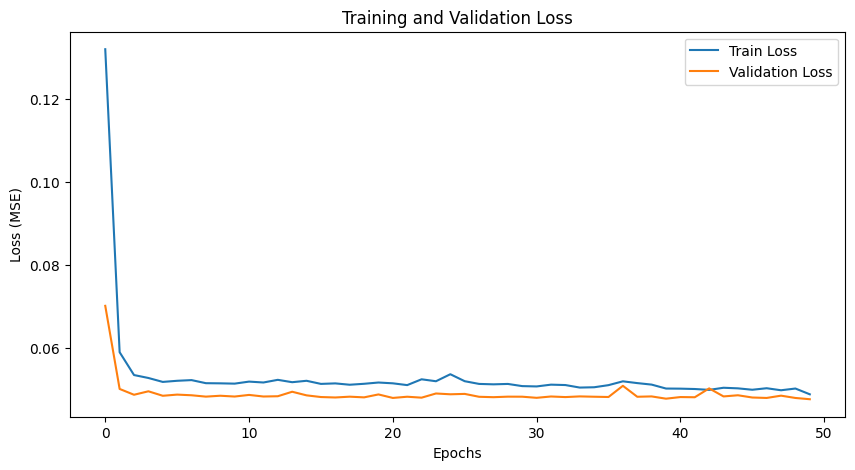

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step


🔹 MSE (Mean Squared Error): 418810.7245
🔹 MAE (Mean Absolute Error): 338.6937
🔹 R² (결정계수): -0.0072
✅ 모델 및 스케일러 저장 완료!


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

# CSV 데이터 로드
df = pd.read_csv("growth_marketing_data.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# 데이터 정규화
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# LSTM 입력 형태 변환
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10  # 10일 데이터를 사용하여 다음 날 예측
X, y = create_sequences(scaled_data, seq_length)

# 데이터 분리
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# LSTM 모델 생성
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    LSTM(50, activation='relu'),
    Dense(X.shape[2])  # 예측할 특성 수만큼 출력층 설정
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 모델 학습
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# 학습 과정 시각화 (손실 값 그래프)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# 모델 평가
y_test_pred = model.predict(X_test)
y_test_pred_rescaled = scaler.inverse_transform(y_test_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

mse = mean_squared_error(y_test_rescaled, y_test_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_test_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_test_pred_rescaled)  # 결정계수 계산

# 성능 평가 결과 출력
print(f"🔹 MSE (Mean Squared Error): {mse:.4f}")
print(f"🔹 MAE (Mean Absolute Error): {mae:.4f}")
print(f"🔹 R² (결정계수): {r2:.4f}")  # 결정계수 출력

# 모델 저장
model.save("lstm_growth_marketing_model.h5")

# 스케일러 저장
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ 모델 및 스케일러 저장 완료!")

###**3. 모델 로딩 및 예측**

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle

# CSV 데이터 로드
df = pd.read_csv("growth_marketing_data.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# 스케일러 로딩
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# 모델 로딩 (손실 함수 지정)
model = load_model("lstm_growth_marketing_model.h5", custom_objects={"mse": tf.keras.losses.MeanSquaredError()})

# 최근 10일 데이터 준비
seq_length = 10
last_seq = df[-seq_length:].values
last_seq_scaled = scaler.transform(last_seq)

# 입력 데이터 형태 변환 (LSTM 입력 차원 맞추기)
X_new = np.array([last_seq_scaled])

# 예측 수행
y_pred_scaled = model.predict(X_new)
y_pred = scaler.inverse_transform(y_pred_scaled)

# 예측 결과 출력
print(f"📊 예측된 방문자 수: {y_pred[0, 0]:.2f}")
print(f"📊 예측된 클릭 수: {y_pred[0, 1]:.2f}")
print(f"📊 예측된 전환 수: {y_pred[0, 2]:.2f}")
print(f"📊 예측된 전환율: {y_pred[0, 3]:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
📊 예측된 방문자 수: 2589.92
📊 예측된 클릭 수: 431.50
📊 예측된 전환 수: 39.98
📊 예측된 전환율: 0.0147


###**4. 특정시기 예측**

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle

# CSV 데이터 로드
df = pd.read_csv("growth_marketing_data.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# 스케일러 로딩
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# 모델 로딩
model = load_model("lstm_growth_marketing_model.h5", custom_objects={"mse": tf.keras.losses.MeanSquaredError()})

# 특정 날짜 입력 (예: "2023-06-15")
target_date = "2023-06-15"
target_date = pd.to_datetime(target_date)

# 특정 날짜 이전 10일 데이터를 가져오기
if target_date not in df.index:
    print("🚨 입력한 날짜가 데이터에 없습니다. 다시 입력하세요.")
else:
    date_index = df.index.get_loc(target_date)

    if date_index < 10:
        print("🚨 해당 날짜 이전의 10일 데이터가 부족합니다. 더 이후 날짜를 선택하세요.")
    else:
        # 직전 10일 데이터 가져오기
        last_seq = df.iloc[date_index-10:date_index].values
        last_seq_scaled = scaler.transform(last_seq)

        # 입력 데이터 형태 변환 (LSTM 입력 차원 맞추기)
        X_new = np.array([last_seq_scaled])

        # 예측 수행
        y_pred_scaled = model.predict(X_new)
        y_pred = scaler.inverse_transform(y_pred_scaled)

        # 예측 결과 출력
        print(f"📊 예측 기준 날짜: {target_date.strftime('%Y-%m-%d')}")
        print(f"📊 예측된 방문자 수: {y_pred[0, 0]:.2f}")
        print(f"📊 예측된 클릭 수: {y_pred[0, 1]:.2f}")
        print(f"📊 예측된 전환 수: {y_pred[0, 2]:.2f}")
        print(f"📊 예측된 전환율: {y_pred[0, 3]:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
📊 예측 기준 날짜: 2023-06-15
📊 예측된 방문자 수: 2767.65
📊 예측된 클릭 수: 529.74
📊 예측된 전환 수: 53.43
📊 예측된 전환율: 0.0191


위 코드에 대한 웹 서비스

app.py

In [ ]:
from flask import Flask, request, jsonify, render_template
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle

app = Flask(__name__)

# 모델 및 데이터 로드
MODEL_PATH = "lstm_growth_marketing_model.h5"
SCALER_PATH = "scaler.pkl"
DATA_PATH = "growth_marketing_data.csv"

model = load_model(MODEL_PATH, custom_objects={"mse": tf.keras.losses.MeanSquaredError()})
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df.set_index("date", inplace=True)

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        target_date = data.get("date")

        if not target_date:
            return jsonify({"error": "날짜를 입력하세요."}), 400

        target_date = pd.to_datetime(target_date)

        if target_date not in df.index:
            return jsonify({"error": "입력한 날짜가 데이터에 없습니다."}), 400

        date_index = df.index.get_loc(target_date)

        if date_index < 10:
            return jsonify({"error": "이 날짜 이전 10일 데이터가 부족합니다."}), 400

        last_seq = df.iloc[date_index-10:date_index].values
        last_seq_scaled = scaler.transform(last_seq)

        X_new = np.array([last_seq_scaled])
        y_pred_scaled = model.predict(X_new)
        y_pred = scaler.inverse_transform(y_pred_scaled)

        result = {
            "date": target_date.strftime("%Y-%m-%d"),
            "predicted_visitors": round(float(y_pred[0, 0]), 2),
            "predicted_clicks": round(float(y_pred[0, 1]), 2),
            "predicted_conversions": round(float(y_pred[0, 2]), 2),
            "predicted_conversion_rate": round(float(y_pred[0, 3]), 4)
        }
        return jsonify(result)

    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5001, debug=True)

index.html

In [ ]:
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>LSTM 예측 서비스</title>
    <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css">
    <style>
        body {
            background-color: #f8f9fa;
        }
        .container {
            max-width: 600px;
            margin-top: 50px;
            background: white;
            padding: 30px;
            border-radius: 10px;
            box-shadow: 0px 0px 15px rgba(0, 0, 0, 0.1);
        }
        .btn-primary {
            width: 100%;
        }
        #result {
            margin-top: 20px;
            padding: 20px;
            background-color: #e9ecef;
            border-radius: 8px;
            display: none;
        }
        .error {
            color: red;
        }
    </style>
</head>
<body>
    <div class="container">
        <h2 class="text-center">📊 LSTM 기반 방문자 예측</h2>
        <p class="text-center">날짜를 입력하면 예측된 방문자 수, 클릭 수, 전환율을 확인할 수 있습니다.</p>

        <form id="predictForm">
            <label for="date" class="form-label">예측할 날짜 선택:</label>
            <input type="date" class="form-control" id="date" required>
            <button type="submit" class="btn btn-primary mt-3">예측하기</button>
        </form>

        <div id="result">
            <h4 class="text-center">📅 예측 결과</h4>
            <p><strong>날짜:</strong> <span id="pred_date"></span></p>
            <p><strong>예측된 방문자 수:</strong> <span id="pred_visitors"></span></p>
            <p><strong>예측된 클릭 수:</strong> <span id="pred_clicks"></span></p>
            <p><strong>예측된 전환 수:</strong> <span id="pred_conversions"></span></p>
            <p><strong>예측된 전환율:</strong> <span id="pred_conversion_rate"></span></p>
        </div>

        <p id="errorMessage" class="error text-center mt-3"></p>
    </div>

    <script>
        document.getElementById("predictForm").addEventListener("submit", function(event) {
            event.preventDefault();

            let dateInput = document.getElementById("date").value;
            if (!dateInput) {
                document.getElementById("errorMessage").textContent = "날짜를 입력하세요.";
                return;
            }

            document.getElementById("errorMessage").textContent = "";

            fetch("/predict", {
                method: "POST",
                headers: {
                    "Content-Type": "application/json"
                },
                body: JSON.stringify({ date: dateInput })
            })
            .then(response => response.json())
            .then(data => {
                if (data.error) {
                    document.getElementById("errorMessage").textContent = data.error;
                    document.getElementById("result").style.display = "none";
                } else {
                    document.getElementById("pred_date").textContent = data.date;
                    document.getElementById("pred_visitors").textContent = data.predicted_visitors;
                    document.getElementById("pred_clicks").textContent = data.predicted_clicks;
                    document.getElementById("pred_conversions").textContent = data.predicted_conversions;
                    document.getElementById("pred_conversion_rate").textContent = data.predicted_conversion_rate;
                    document.getElementById("result").style.display = "block";
                }
            })
            .catch(error => {
                document.getElementById("errorMessage").textContent = "서버 오류가 발생했습니다.";
                document.getElementById("result").style.display = "none";
            });
        });
    </script>
</body>
</html>

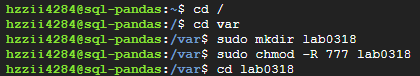

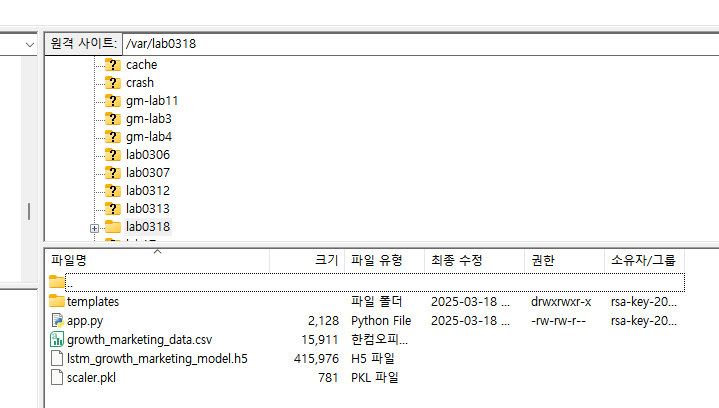

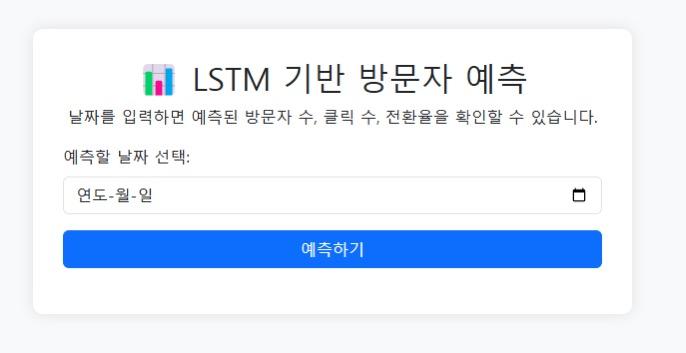 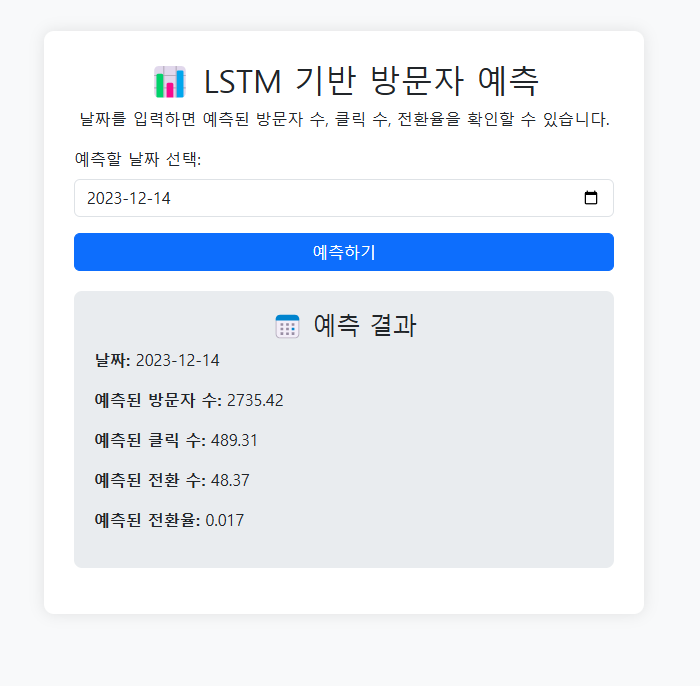



---

#**특강**

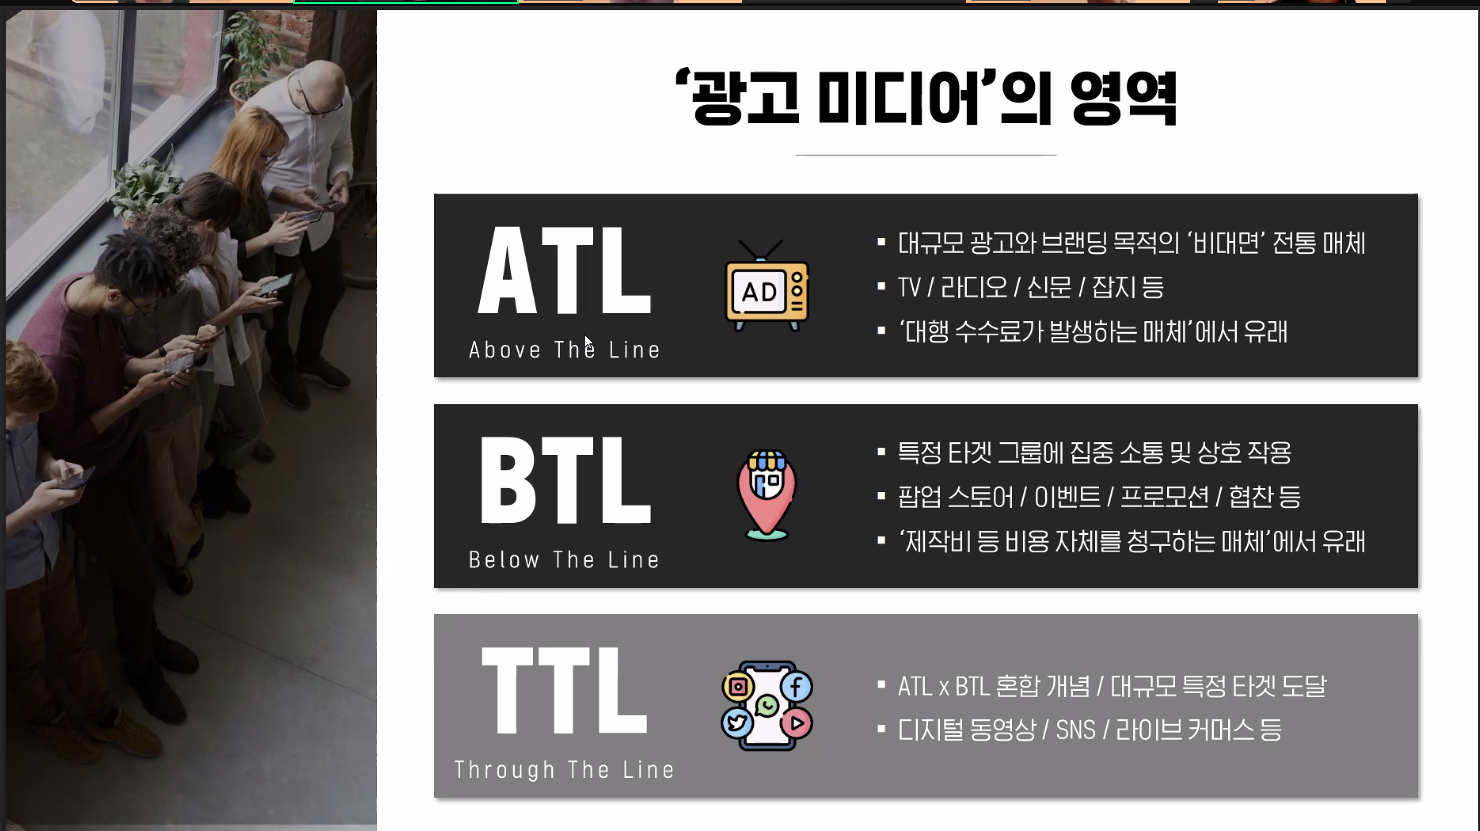

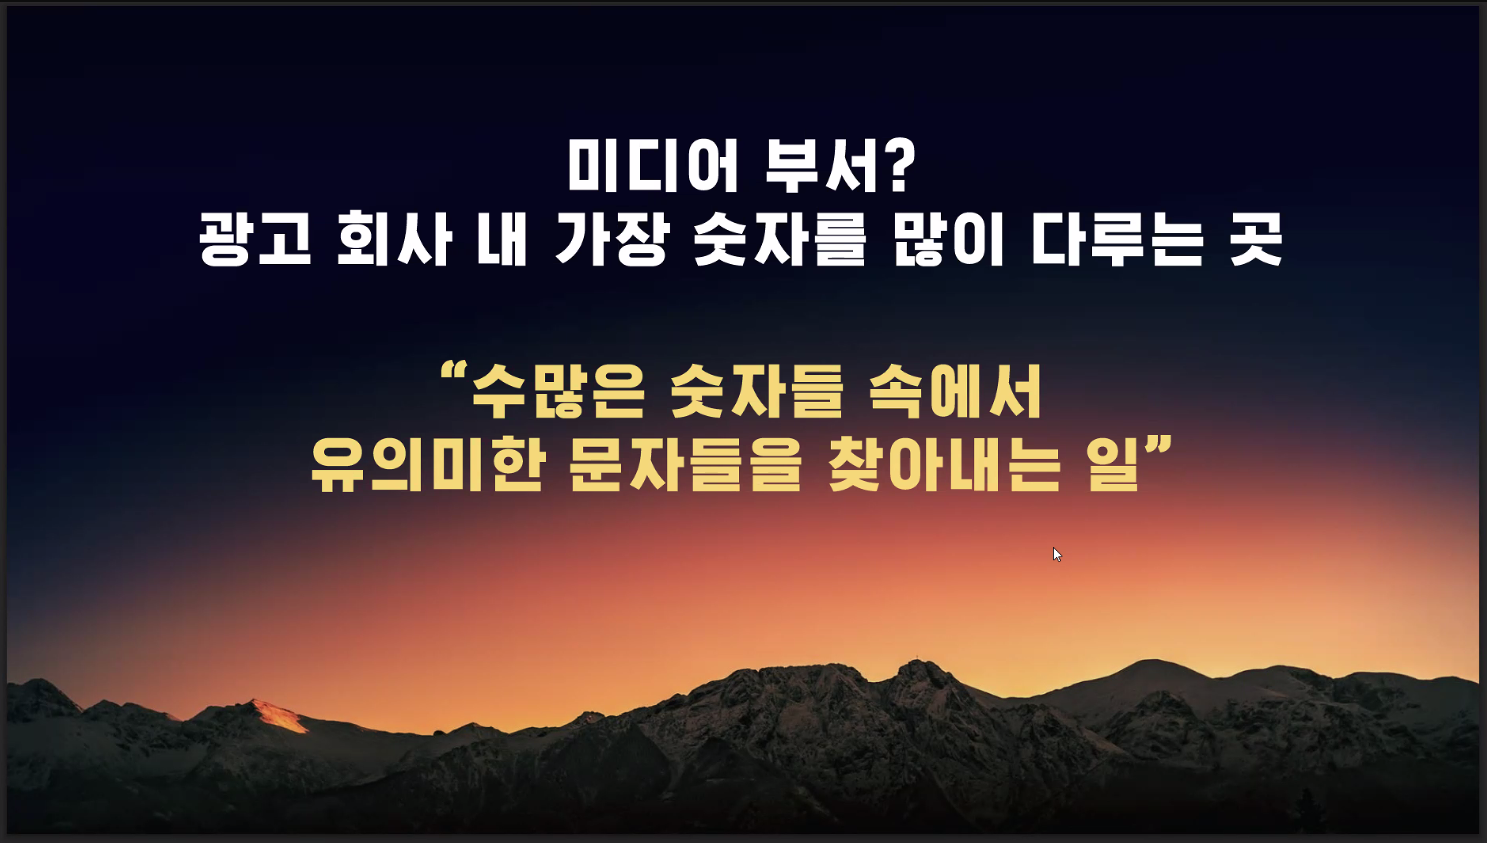

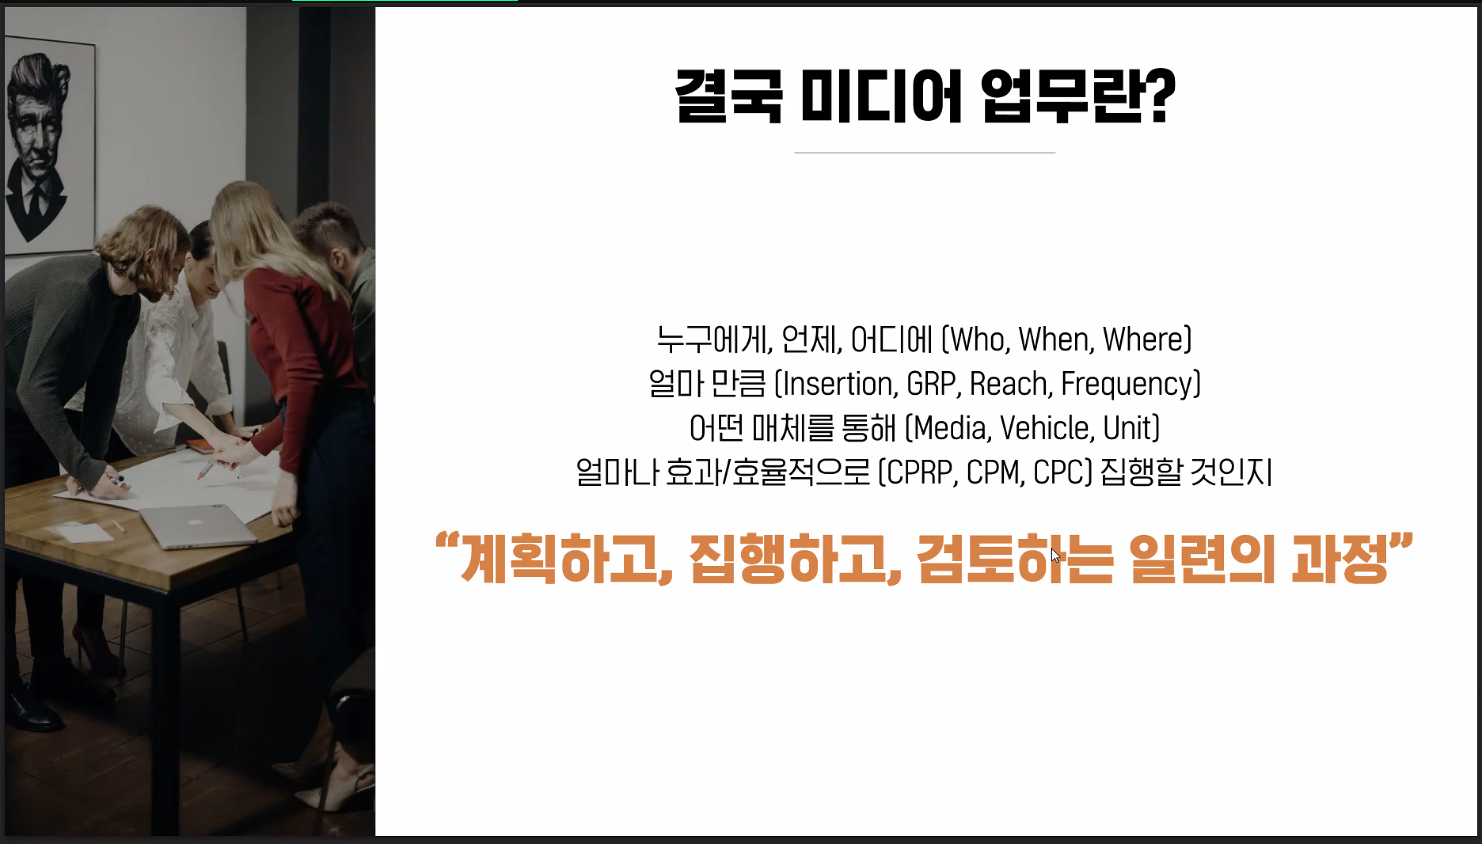